### 📊 Análisis de Datos y Modelo Predictivo de Riesgo de Enfermedad Cardíaca

##### 📖 Descripción del proyecto

En esta notebook se desarrolla un análisis exploratorio de datos (EDA) y la construcción de modelos predictivos utilizando el dataset **Heart Disease Analysis**.

El objetivo es comprender las características clínicas de los pacientes, explorar las relaciones entre las variables y desarrollar un modelo capaz de predecir la presencia de enfermedad cardíaca a partir de información clínica.

#### 🎯 Objetivos

Principales objetivos de la notebook:

- Explorar la estructura y calidad del conjunto de datos.
- Realizar un análisis exploratorio de las variables.
- Identificar valores faltantes y posibles valores atípicos.
- Analizar la distribución de las variables numéricas y categóricas.
- Estudiar la relación entre las variables predictoras y la variable objetivo.
- Preprocesar los datos para su utilización en modelos predictivo.
- Construir un pipeline de procesamiento utilizando scikit-learn.
- Entrenar y comparar distintos modelos predictivos.
- Evaluar el desempeño de los modelos mediante métricas apropiadas.

In [57]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, silhouette_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

#Libreiras de pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
# Selección de variables
from sklearn.feature_selection import SelectKBest, f_classif
#Validaciones cruzadas
from sklearn.model_selection import cross_val_score, GridSearchCV
import os

print ("librerias ok")

librerias ok


### 1. Obtención de los datos

In [58]:
# Directorio actual
print(os.getcwd())

d:\Josefina\Proyectos\Datascience\Curso_ML\Modelos_ML\heart_disease_uci


In [59]:
#Abrir el df
df = pd.read_csv("../data/heart_disease_uci.csv")

### 2. Analisis exploratorio de los datos (EDA)

In [60]:
# Primero comenzar a explorar el dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [61]:
#Cuantas filas y columnas tengo
df.shape
print(f"Cantidad filas: {df.shape[0]}")
print(f"Cantidad columnas: {df.shape[1]}")

Cantidad filas: 920
Cantidad columnas: 16


In [62]:
#Analisis descriptivos
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


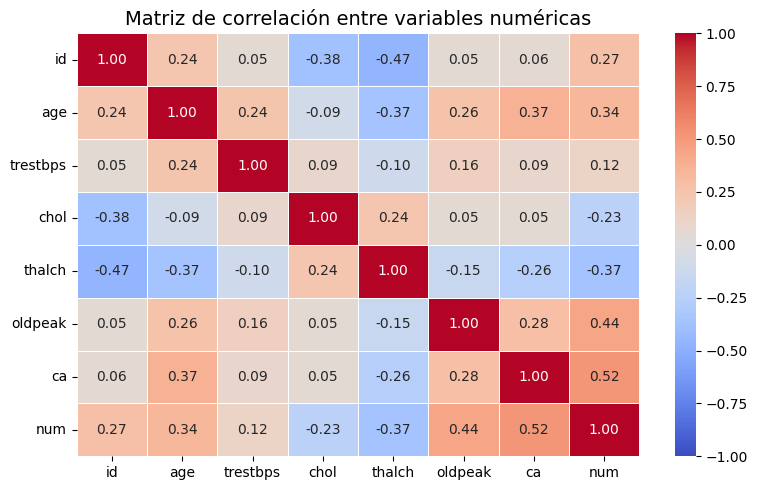

In [63]:
#Matriz de correlacion entre todas las variables para evitar que se duplique la informacion

plt.figure(figsize=(8,5))

corr_matrix = df.corr(numeric_only=True)

# sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white", 
    vmin=-1,
    vmax=1
)
plt.title("Matriz de correlación entre variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

#No hay ninguna variable que este altamente correlacionada entre si

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='str')


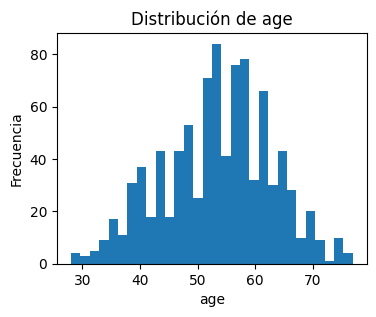

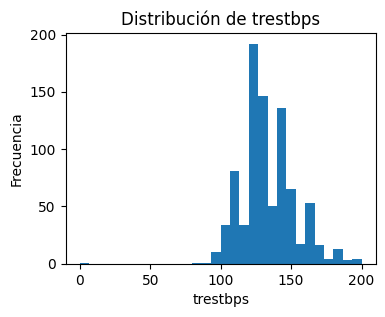

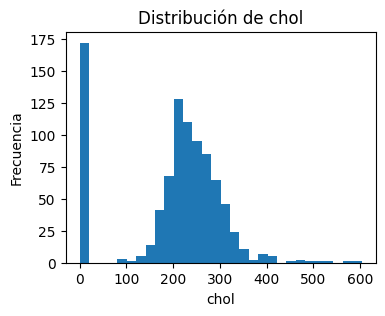

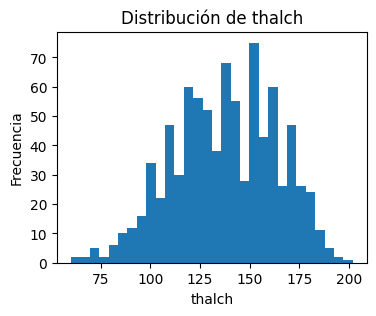

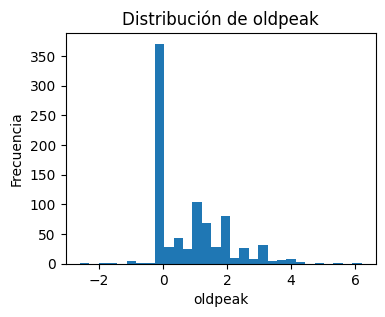

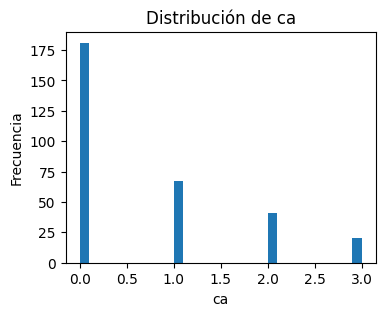

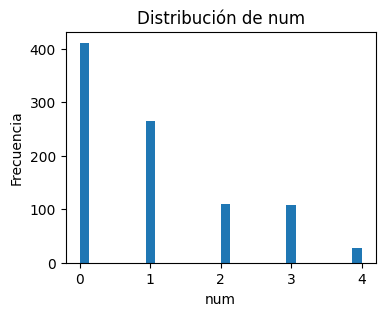

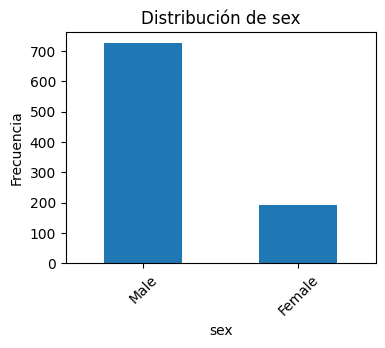

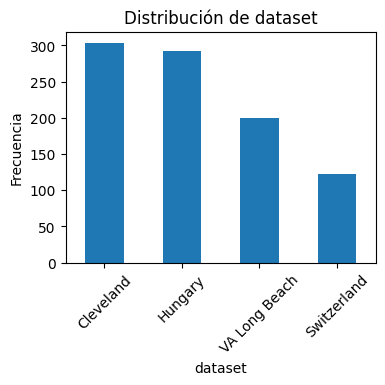

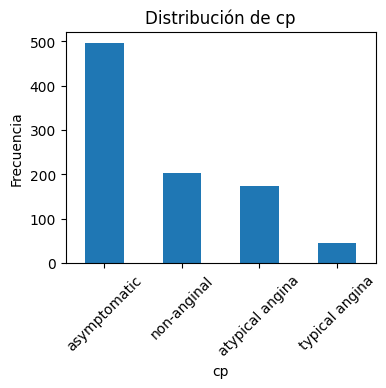

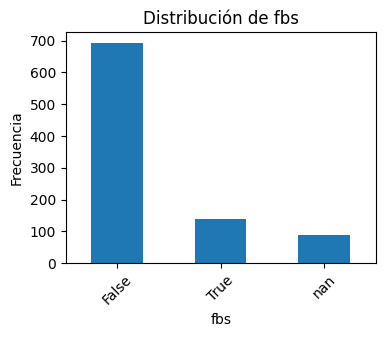

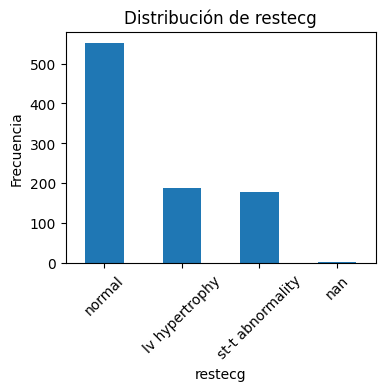

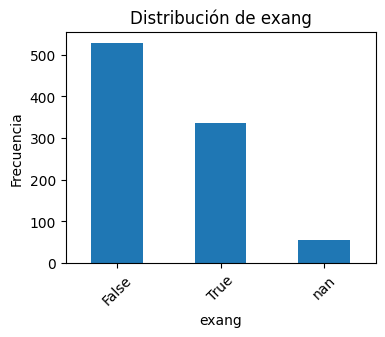

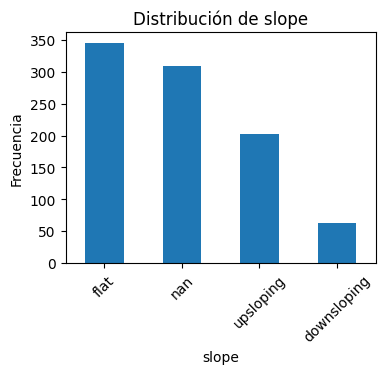

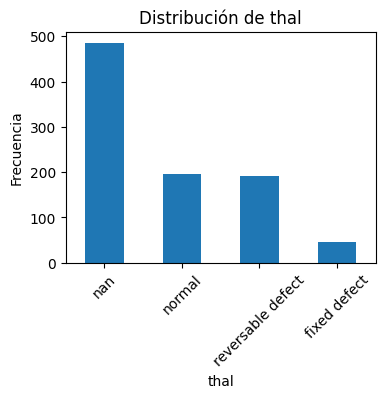

In [64]:
#Plot de distribucion

# Variables numéricas
num_cols = df.select_dtypes(include=["int64", "float64"]).drop(columns="id").columns

print(num_cols)
for col in num_cols:
    plt.figure(figsize=(4,3))
    df[col].hist(bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(False)
    plt.show()

#Variables categoricas
cat_cols = df.select_dtypes(include=["object", "string"]).columns

for col in cat_cols:
    plt.figure(figsize=(4,3))
    df[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.show()


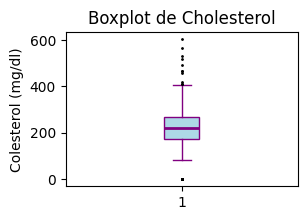

In [65]:
#Boxplots

plt.figure(figsize=(3,2))

plt.boxplot(
    df["chol"].dropna(),
    patch_artist=True,  # Permite colorear la caja
    boxprops=dict(facecolor="lightblue", color="purple"),
    medianprops=dict(color="purple", linewidth=2),
    whiskerprops=dict(color="purple"),
    capprops=dict(color="purple"),
    flierprops=dict(
        marker='o',
        markersize=1,
        markerfacecolor='black',
        markeredgecolor='black'
    )
)
plt.title("Boxplot de Cholesterol")
plt.ylabel("Colesterol (mg/dl)")
plt.show()

In [66]:
#Cuales son los tipos de clasificaciones en cada set de datos categóricos
print("CP", df['cp'].unique())
print("SEX",df['sex'].unique())
print("DATASET", df['dataset'].unique())
print("RESTECG", df['restecg'].unique())
print("EXANG", df['exang'].unique())
print("FBS", df['fbs'].unique())
print("SLOPE", df['slope'].unique())
print("THAL", df['thal'].unique())


CP <StringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str
SEX <StringArray>
['Male', 'Female']
Length: 2, dtype: str
DATASET <StringArray>
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
Length: 4, dtype: str
RESTECG <StringArray>
['lv hypertrophy', 'normal', 'st-t abnormality', nan]
Length: 4, dtype: str
EXANG [False True nan]
FBS [True False nan]
SLOPE <StringArray>
['downsloping', 'flat', 'upsloping', nan]
Length: 4, dtype: str
THAL <StringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str


### 3. Preparación de los datos

##### Explicación de algunas de las variables:
##### Variables númericas
- `Age (Edad)`: edad del paciente
- `trestbps (Presión arterial)`: presion arterial en reposo medida en mm Hg. 
- `Chol (Colesterol)`: Nievel de colesterol sérico en mg/dl.
- `Thalch (Frecuencia cardíaca)`: Frecuencia cárdiaca maxima alcanzada. 

##### Variables categóricas
- `Sex`: Female y Male 
- `cp (Tipo de dolor)`: Describe el tipo de dolor en el pecho con categorías como "Typical Angina" o  asymptomatic 
- `thal (Prueba de talio)`: resune los resultados de una prueba de esfuerzo con talio 
- `restecg (Electrocardiograma)`: multiples categorias de diagnosticos 


##### Variables booleanas
- `fbs (Azúcar en sangre)`: Indica si el azúcar en sangre en ayunas es mayor a 120 mg/dl (T/F)
- `Exang (angina)`: Presencia de angina inducida por ejercicio 

##### Variables objetivo
- `num (variable objetivo)`: Grado de enfermedad cardíaca (0-4), que combvertiremos en binaria para clasificación


C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_252\1800651465.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x ="num", palette="pastel")


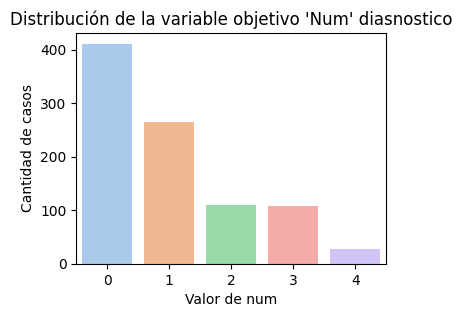

In [67]:
#Profundizamos el analisis en la variable objetivo

plt.figure(figsize=(4,3))
sns.countplot(data = df, x ="num", palette="pastel")
plt.title ("Distribución de la variable objetivo 'Num' diasnostico")
plt.xlabel ("Valor de num")
plt.ylabel ("Cantidad de casos")
plt.show()



Esto muestra que la mayoria de los casos los pacientes no tiene ningun riesgo de enfermedad (0)

Pero si agrupamos 1-4 se iguala a los que no tienen ningun riesgo de enfermedad, mas alla de la magnitud tenemos:
- 0 sin riesgo 
- 1-4, si tiene riesgo enfermedadees pero de distintas magnitudes

Entonces la primera pregunta podría ser solamente si tiene o no riesgo de enfermedad. Sin importar el grado o magnitud de la enfermedad.



C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_252\544933625.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='enfermo', palette="pastel")


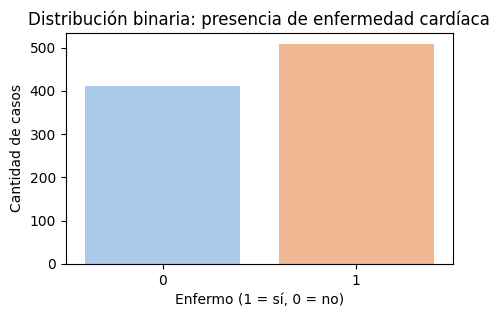

In [68]:
# Creamos una nueva columna binaria: 'enfermo'
df['enfermo'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Visualizamos su distribución
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='enfermo', palette="pastel")
plt.title("Distribución binaria: presencia de enfermedad cardíaca")
plt.xlabel("Enfermo (1 = sí, 0 = no)")
plt.ylabel("Cantidad de casos")
plt.show()

C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_252\2323498453.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=valores_nulos.index, x=valores_nulos.values, palette="pastel")


ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64


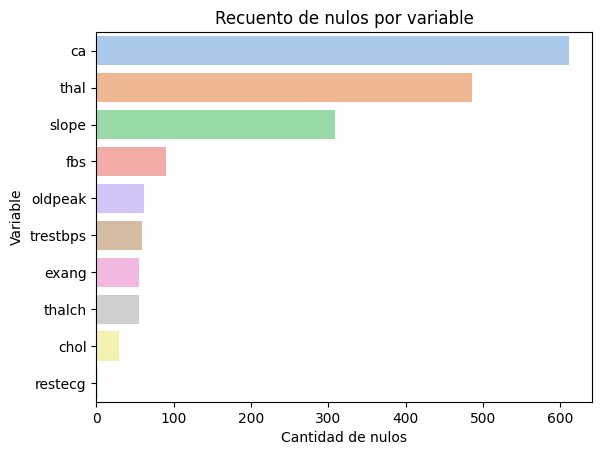

id           0.0
age          0.0
sex          0.0
dataset      0.0
cp           0.0
trestbps     6.4
chol         3.3
fbs          9.8
restecg      0.2
thalch       6.0
exang        6.0
oldpeak      6.7
slope       33.6
ca          66.4
thal        52.8
num          0.0
enfermo      0.0
dtype: float64


In [69]:
# Analisis de valores nulls por cada variable

valores_nulos = df.isnull().sum()

#Me quedo solo con las columnas que tienen valores nulos
valores_nulos = valores_nulos[valores_nulos > 0].sort_values(ascending=False)
print(valores_nulos)

#Los visualizamos
plt.Figure(figsize=(5, 4))
# plt.barh(valores_nulos.index, valores_nulos.values)
sns.barplot(y=valores_nulos.index, x=valores_nulos.values, palette="pastel")
plt.title( "Recuento de nulos por variable")
plt.xlabel("Cantidad de nulos")
plt.ylabel("Variable")
plt.show()


#Si lo hacemos en porcentajes del total
porcentaje_nulos = round((df.isnull().sum() / len(df)) * 100, 1)
print(porcentaje_nulos)

Las variables slope; ca; thal son las que mas % de valores faltantes tienen

Tenemos que preguntarnos si son relevantes o no

Por ahora vamos a imputar valores para considerarlas

- Para variable numerica: media o mediana
- Para variable categorica: moda, pero despues las voy a tener que codificar

Lo primero que vamos a hacer es dividir las variables segun su tipo


In [70]:
#Solo me quedo con los nombres de esas variables y las pongo en una lista
variables_numericas = df.select_dtypes(["int64", "float64"]).columns.drop(["id", "num"]).to_list()
print(variables_numericas)

variables_categoricas = df.select_dtypes(["object"]).columns.to_list()
print(variables_categoricas)

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'enfermo']
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_252\1236175173.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = df.select_dtypes(["object"]).columns.to_list()


### 4. Pipeline de Preprocesamiento

In [71]:
# Imputacion

variables_numericas = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak'] # se exluyen , 'ca', 'enfermedad'
variables_categoricas = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'] #  se exluye'dataset', 

#Pipeline para variables numericas: imputacion por media + escalado
pipeline_numerico = Pipeline ( steps = [
    ("imputacion", SimpleImputer (strategy = "mean")),
    ("escalado", StandardScaler())
])


#Pipeline para variables categoricas: imputacion por moda + codificacion one-hot
pipeline_categorico = Pipeline ( steps = [
    ("imputacion", SimpleImputer (strategy = "most_frequent")),
    ("codificacion", OneHotEncoder(handle_unknown="ignore"))
])


#Pipeline general de preprocesamiento
preprocesador = ColumnTransformer (transformers= [
    ("num", pipeline_numerico, variables_numericas),
    ("cat", pipeline_categorico, variables_categoricas)
])

modelo = Pipeline(steps=[
    ("preprocesamiento", preprocesador),
    ("clasificador", LogisticRegression(max_iter=1000))
])
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}


### 5. Modelo predictivo

In [72]:
# Separar variables predictoras y objetivo
X = df.drop(columns=["id", "dataset", "num", "enfermo"])
y = df["enfermo"]

In [73]:
#Dividir el dataset entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
#Entreno el modelo con los piptelines anteriores
modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [75]:
#Prediccion del modelo con el testeo
y_pred = modelo.predict(X_test)

### 6. Evaluación del modelo

Accuracy: 0.8152173913043478
              precision    recall  f1-score   support

           0       0.77      0.79      0.78        75
           1       0.85      0.83      0.84       109

    accuracy                           0.82       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.82      0.82      0.82       184

[[59 16]
 [18 91]]


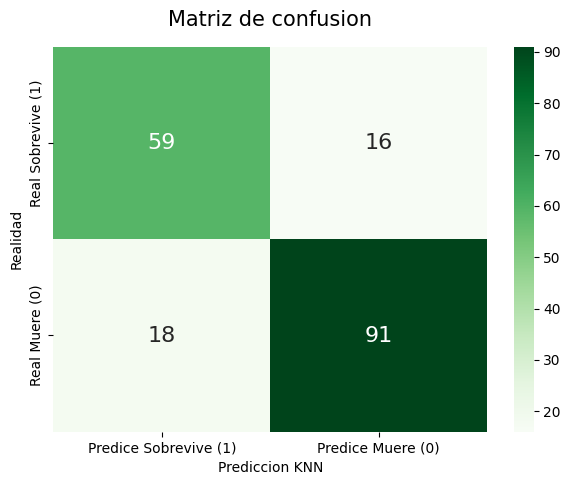


               precision    recall  f1-score   support

           0       0.77      0.79      0.78        75
           1       0.85      0.83      0.84       109

    accuracy                           0.82       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.82      0.82      0.82       184



In [76]:
# Vemos las metricas
cm = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(cm)


# 08. hacemos un plot para entender mejor las metricas

plt.figure (figsize = (7,5))
#Se invierten las etiquetas, se actualizan los textos para que coincidan con el nievo orden.
sns.heatmap (cm, annot = True, fmt ="d", cmap ="Greens", annot_kws = {"size": 16},
             xticklabels = ["Predice Sobrevive (1)", "Predice Muere (0)"],
            yticklabels = ["Real Sobrevive (1)", "Real Muere (0)"])

plt.title(f"Matriz de confusion", fontsize = 15, pad =15)
plt.ylabel("Realidad")
plt.xlabel("Prediccion KNN")
plt.show()
print ("\n", classification_report(y_test, y_pred)) 

In [77]:
#Ejemplo de como puedo probar varios modelos al mismo tiempo
for nombre, clasificador in modelos.items(): #modelos lo seteamos mas arriba con todos los Pipelines

    pipeline = Pipeline([
        ("preprocesamiento", preprocesador),
        ("clasificador", clasificador)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f"{nombre}: {accuracy_score(y_test, y_pred):.3f}")

Regresión Logística: 0.815
Random Forest: 0.821
KNN: 0.864


### 7. Conclusión
Variable objetivo es: 0 = No enfermo / 1 = Enfermo

- El valor de Accuracy = 0.86 muestra que el 86% de todos los pacientes fueron clasificados correctamente, independientemente de si estaban enfermos o no.
- Cuando el modelo dice que una persona está sana, acierta el 83% de las veces (0). Es decir que el 16% restante fueron clasificados erróneamente como enfermos (falsos positivos respecto de la clase 1).
- De todos los pacientes que el modelo predijo como enfermos, el 89% realmente estaban enfermos (1). Donde solo el 11% fueron falsas alarmas.
- En cuanto al Recall = 0.88, nos dice que de todos los pacientes que realmente estaban enfermos, el modelo detectó correctamente al 88%.
- Con respecto al F1-Score dice que el modelo presenta un mejor desempeño para identificar pacientes enfermos (clase 1) que para identificar pacientes sanos (clase 0).
- Cuando se probaron varios modelos el KNN fue el que mostro mejor accuracy